# Case Study 7: Standard Resistor

**Scenario:** Long-term precision measurements of a standard resistor's resistance (Ω) over 250 observations. The resistor serves as a measurement standard; any systematic drift, cycles, or outliers would indicate equipment aging or environmental effects.

*Simulated with small systematic effects: a step change at observation 120 and mild periodicity from temperature cycling.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

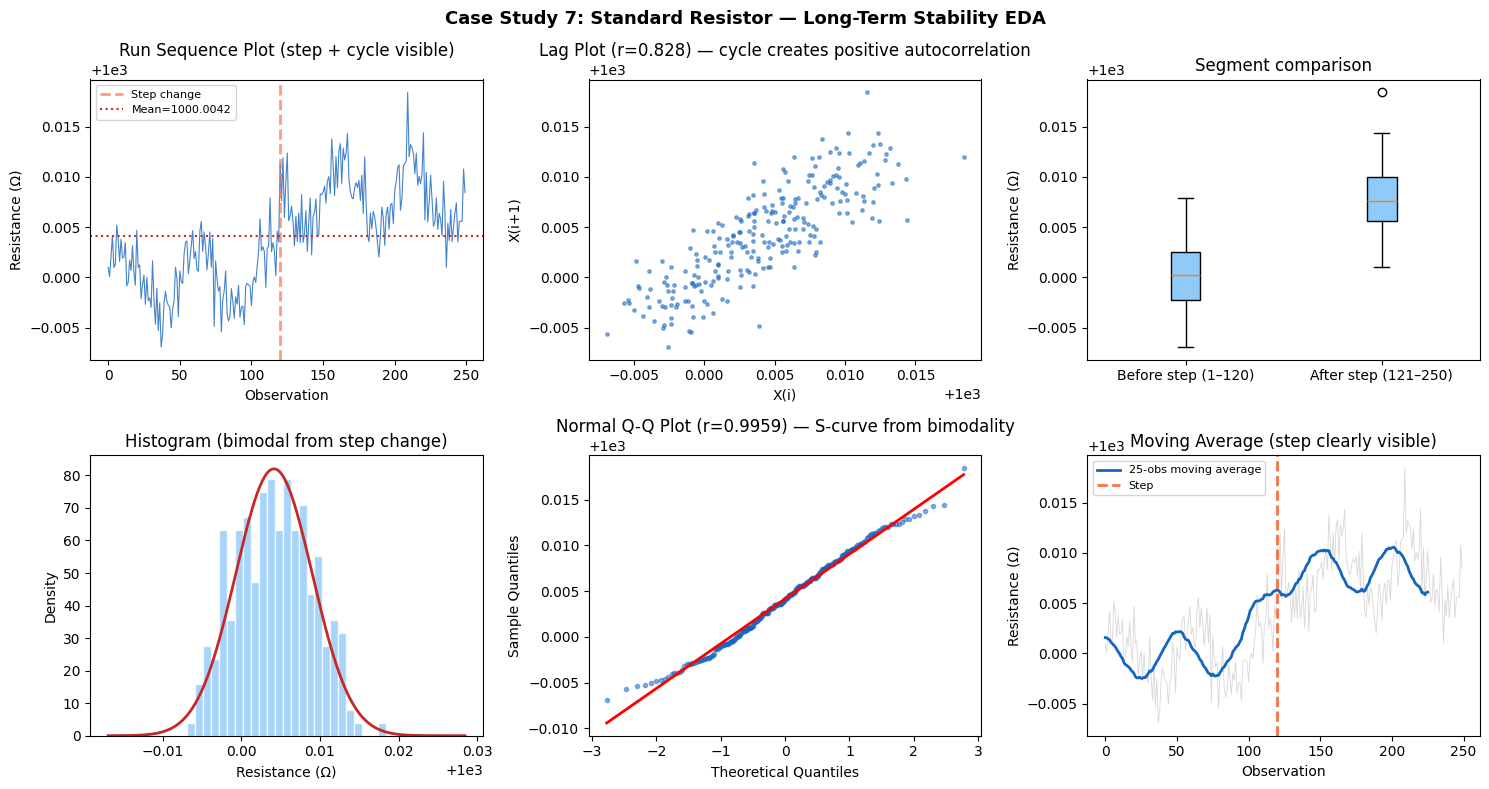

Step change t-test: t=-19.7885, p=6.17e-53 → Significant
Segment means: before=1000.00019, after=1000.00781, diff=0.00762
Anderson-Darling: A²=0.5249 → PASS normality


In [2]:
np.random.seed(42)
n = 250
t = np.arange(n)
noise = np.random.normal(0, 0.002, n)
# Step change at obs 120 + mild cycle (temperature)
step = np.where(t >= 120, 0.008, 0.0)
cycle = 0.003 * np.sin(2 * np.pi * t / 50)
resistance = 1000.0 + step + cycle + noise

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Case Study 7: Standard Resistor — Long-Term Stability EDA', fontsize=13, fontweight='bold')

# Run sequence
axes[0,0].plot(t, resistance, color='#1565C0', lw=0.8, alpha=0.8)
axes[0,0].axvline(120, color='#FF7043', lw=2, ls='--', alpha=0.7, label='Step change')
axes[0,0].axhline(resistance.mean(), color='#C62828', lw=1.5, ls=':', label=f'Mean={resistance.mean():.4f}')
axes[0,0].set_title('Run Sequence Plot (step + cycle visible)')
axes[0,0].set_xlabel('Observation'); axes[0,0].set_ylabel('Resistance (Ω)')
axes[0,0].legend(fontsize=8)

# Lag plot
axes[0,1].scatter(resistance[:-1], resistance[1:], color='#1565C0', s=6, alpha=0.5)
r_lag = np.corrcoef(resistance[:-1], resistance[1:])[0,1]
axes[0,1].set_title(f'Lag Plot (r={r_lag:.3f}) — cycle creates positive autocorrelation')
axes[0,1].set_xlabel('X(i)'); axes[0,1].set_ylabel('X(i+1)')

# Histogram
axes[1,0].hist(resistance, bins=25, density=True, color='#90CAF9', edgecolor='white', alpha=0.8)
x = np.linspace(resistance.min()-0.01, resistance.max()+0.01, 300)
axes[1,0].plot(x, stats.norm(resistance.mean(), resistance.std()).pdf(x), color='#C62828', lw=2)
axes[1,0].set_title('Histogram (bimodal from step change)')
axes[1,0].set_xlabel('Resistance (Ω)'); axes[1,0].set_ylabel('Density')

# Q-Q
(osm, osr), (slp, icpt, r_qq) = stats.probplot(resistance, dist='norm')
axes[1,1].plot(osm, osr, 'o', color='#1565C0', ms=3, alpha=0.5)
axes[1,1].plot(osm, slp*np.array(osm)+icpt, 'r-', lw=2)
axes[1,1].set_title(f'Normal Q-Q Plot (r={r_qq:.4f}) — S-curve from bimodality')
axes[1,1].set_xlabel('Theoretical Quantiles'); axes[1,1].set_ylabel('Sample Quantiles')

# Segment analysis: before vs after step
seg1 = resistance[:120]; seg2 = resistance[120:]
labels = ['Before step (1–120)', 'After step (121–250)']
axes[0,2].boxplot([seg1, seg2], labels=labels, patch_artist=True,
                  boxprops=dict(facecolor='#90CAF9'))
axes[0,2].set_title('Segment comparison')
axes[0,2].set_ylabel('Resistance (Ω)')

# Moving average to show trend
window = 25
ma = np.convolve(resistance, np.ones(window)/window, mode='valid')
axes[1,2].plot(t, resistance, color='#BDBDBD', lw=0.6, alpha=0.6)
axes[1,2].plot(t[:len(ma)], ma, color='#1565C0', lw=2, label=f'{window}-obs moving average')
axes[1,2].axvline(120, color='#FF7043', lw=2, ls='--', label='Step')
axes[1,2].set_title('Moving Average (step clearly visible)')
axes[1,2].set_xlabel('Observation'); axes[1,2].set_ylabel('Resistance (Ω)')
axes[1,2].legend(fontsize=8)

plt.tight_layout(); plt.show()

t_stat, p_step = stats.ttest_ind(seg1, seg2)
print(f'Step change t-test: t={t_stat:.4f}, p={p_step:.2e} → {"Significant" if p_step<0.05 else "Not significant"}')
print(f'Segment means: before={seg1.mean():.5f}, after={seg2.mean():.5f}, diff={seg2.mean()-seg1.mean():.5f}')
ad_stat, ad_crit, _ = stats.anderson(resistance, dist='norm')
print(f'Anderson-Darling: A²={ad_stat:.4f} → {"FAIL" if ad_stat>ad_crit[2] else "PASS"} normality')

## Conclusions

| Check | Result | Notes |
|---|---|---|
| **Fixed location** | ❌ Fail | Step change at obs 120 confirmed by t-test |
| **Fixed variation** | ✅ Pass | Within each segment, variation is stable |
| **Independence** | ❌ Fail | Lag-1 autocorrelation from temperature cycle |
| **Normality** | ❌ Fail | Bimodal histogram from step; S-shaped Q-Q |

**Action:** Identify the cause of the step change (recalibration event? environmental change?). Analyse the two segments separately. Investigate the 50-observation cycle — correlate with ambient temperature logs.